In [1]:
!pip install gymnasium torch numpy matplotlib

In [2]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

In [3]:
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("State size:", state_dim)
print("Action size:", action_dim)

State size: 4
Action size: 2


In [4]:
GAMMA = 0.99
LR = 0.001
BATCH_SIZE = 64
MEMORY_SIZE = 10000

EPSILON = 1.0
EPSILON_DECAY = 0.995
EPSILON_MIN = 0.01

TARGET_UPDATE = 10
EPISODES = 200

In [5]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.fc(x)

In [6]:
memory = deque(maxlen=MEMORY_SIZE)

def store_transition(state, action, reward, next_state, done):
    memory.append((state, action, reward, next_state, done))

In [7]:
policy_net = DQN()
target_net = DQN()

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LR)
loss_fn = nn.MSELoss()

In [8]:
def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    else:
        state = torch.FloatTensor(state).unsqueeze(0)
        return torch.argmax(policy_net(state)).item()

In [9]:
def train():
    if len(memory) < BATCH_SIZE:
        return

    batch = random.sample(memory, BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    current_q = policy_net(states).gather(1, actions).squeeze()
    next_q = target_net(next_states).max(1)[0]

    target_q = rewards + GAMMA * next_q * (1 - dones)

    loss = loss_fn(current_q, target_q.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [10]:
rewards_list = []
epsilon = EPSILON

for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0

    while True:
        action = select_action(state, epsilon)
        next_state, reward, done, _, _ = env.step(action)

        store_transition(state, action, reward, next_state, done)
        train()

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_list.append(total_reward)

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode {episode}, Reward: {total_reward}")

Episode 0, Reward: 14.0
Episode 1, Reward: 16.0
Episode 2, Reward: 11.0
Episode 3, Reward: 13.0


/tmp/ipykernel_6195/3951338505.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor(states)


Episode 4, Reward: 17.0
Episode 5, Reward: 19.0
Episode 6, Reward: 37.0
Episode 7, Reward: 13.0
Episode 8, Reward: 17.0
Episode 9, Reward: 35.0
Episode 10, Reward: 69.0
Episode 11, Reward: 30.0
Episode 12, Reward: 24.0
Episode 13, Reward: 35.0
Episode 14, Reward: 31.0
Episode 15, Reward: 26.0
Episode 16, Reward: 14.0
Episode 17, Reward: 15.0
Episode 18, Reward: 19.0
Episode 19, Reward: 25.0
Episode 20, Reward: 12.0
Episode 21, Reward: 26.0
Episode 22, Reward: 11.0
Episode 23, Reward: 11.0
Episode 24, Reward: 23.0
Episode 25, Reward: 38.0
Episode 26, Reward: 12.0
Episode 27, Reward: 27.0
Episode 28, Reward: 30.0
Episode 29, Reward: 21.0
Episode 30, Reward: 14.0
Episode 31, Reward: 15.0
Episode 32, Reward: 11.0
Episode 33, Reward: 17.0
Episode 34, Reward: 18.0
Episode 35, Reward: 40.0
Episode 36, Reward: 19.0
Episode 37, Reward: 12.0
Episode 38, Reward: 19.0
Episode 39, Reward: 55.0
Episode 40, Reward: 15.0
Episode 41, Reward: 26.0
Episode 42, Reward: 18.0
Episode 43, Reward: 36.0
Episod

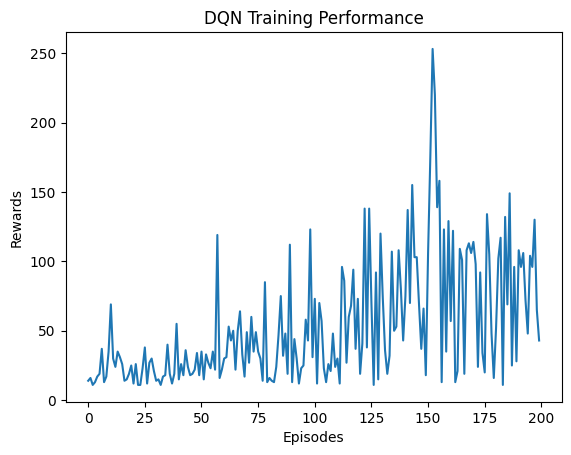

In [11]:
plt.plot(rewards_list)
plt.xlabel("Episodes")
plt.ylabel("Rewards")
plt.title("DQN Training Performance")
plt.show()

In [12]:
state, _ = env.reset()
done = False

while not done:
    state_tensor = torch.FloatTensor(state).unsqueeze(0)
    action = torch.argmax(policy_net(state_tensor)).item()
    state, _, done, _, _ = env.step(action)

env.close()